<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_KiDS_V10_CatalogueMatched_BaryonicAudit_DOWNLOAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM KiDS V10 — Catalogue-Matched Baryonic Burden Audit and Promotion Test

**Notebook:** `ECSM_KiDS_V10_CatalogueMatched_BaryonicAudit_DOWNLOAD.ipynb`

V10 attempts to promote the V8/V9 KiDS LePhare weak-lensing bridge into a catalogue-matched baryonic-burden test.

It does three things:

1. Loads the KiDS-1000 `PneE` bandpower vector and covariance.
2. Loads the KiDS DR4 bright-sample LePhare stellar-mass catalogue.
3. Searches the public KiDS repository for an exact object-level foreground-lens catalogue with RA/DEC/redshift/bin/weight fields.

If an exact object-level foreground catalogue is found, V10 tries to construct a catalogue-matched stellar-burden driver. If it is not found, V10 records that as a data-boundary result and falls back to the V9 physical LePhare lens-bin burden for comparison.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CELL 01 — SETUP
import os, re, json, math, shutil, zipfile, urllib.request, warnings
from pathlib import Path
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore", category=RuntimeWarning)
try:
    from astropy.io import fits
    from astropy.coordinates import SkyCoord
    import astropy.units as u
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "astropy"])
    from astropy.io import fits
    from astropy.coordinates import SkyCoord
    import astropy.units as u
import matplotlib.pyplot as plt
OUT = Path("/content/ecsm_kids_v10_catalogue_matched_baryonic_audit_out")
DATA = OUT / "data"; TAB = OUT / "tables"; FIG = OUT / "figures"
for p in [OUT, DATA, TAB, FIG]: p.mkdir(parents=True, exist_ok=True)
def banner(txt):
    print("\n" + "="*72); print(txt); print("="*72)
def native_array(a):
    arr = np.asarray(a)
    if getattr(arr.dtype, "byteorder", "=") not in ("=", "|"):
        arr = arr.byteswap().view(arr.dtype.newbyteorder("="))
    return arr
def table_to_df(data):
    cols = {}
    for name in data.names:
        vals = np.asarray(data[name])
        if getattr(vals.dtype, "byteorder", "=") not in ("=", "|"):
            vals = vals.byteswap().view(vals.dtype.newbyteorder("="))
        cols[name] = vals
    return pd.DataFrame(cols)
def normalize_nz(z, n):
    z = np.asarray(z, float); n = np.nan_to_num(np.asarray(n, float), nan=0.0, posinf=0.0, neginf=0.0)
    n = np.clip(n, 0, None)
    area = np.trapezoid(n, z) if len(z) > 1 else 0.0
    return np.zeros_like(n) if area <= 0 else n / area
def nz_mean_sigma(z, n):
    nn = normalize_nz(z, n)
    if nn.sum() <= 0: return np.nan, np.nan
    mu = np.trapezoid(z * nn, z); var = np.trapezoid((z - mu)**2 * nn, z)
    return float(mu), float(np.sqrt(max(var, 0.0)))
def choose_col(cols, patterns):
    for pat in patterns:
        hits = [c for c in cols if re.search(pat, str(c), re.I)]
        if hits: return hits[0]
    return None
print("Output:", OUT)

Output: /content/ecsm_kids_v10_catalogue_matched_baryonic_audit_out


In [ ]:
# CELL 02 — DOWNLOAD / LOCATE KiDS Cat_to_Obs_K1000_P1 REPOSITORY
banner("CELL 02 — DOWNLOAD / LOCATE KiDS Cat_to_Obs_K1000_P1 REPOSITORY")
repo_zip = DATA / "Cat_to_Obs_K1000_P1-master.zip"
repo_parent = DATA / "Cat_to_Obs_K1000_P1_repo"
repo_root = repo_parent / "Cat_to_Obs_K1000_P1-master"
if not repo_root.exists():
    repo_parent.mkdir(parents=True, exist_ok=True)
    url = "https://github.com/KiDS-WL/Cat_to_Obs_K1000_P1/archive/refs/heads/master.zip"
    print("Downloading:", url)
    urllib.request.urlretrieve(url, repo_zip)
    with zipfile.ZipFile(repo_zip, "r") as zf: zf.extractall(repo_parent)
print("Repository root:", repo_root)
for p in sorted(repo_root.iterdir())[:30]: print(" -", p.name)


CELL 02 — DOWNLOAD / LOCATE KiDS Cat_to_Obs_K1000_P1 REPOSITORY
Downloading: https://github.com/KiDS-WL/Cat_to_Obs_K1000_P1/archive/refs/heads/master.zip
Repository root: /content/ecsm_kids_v10_catalogue_matched_baryonic_audit_out/data/Cat_to_Obs_K1000_P1_repo/Cat_to_Obs_K1000_P1-master
 - .gitignore
 - 2pt_data_to_fits
 - Calc_1pt_Stats
 - Calc_2pt_Stats
 - Cat2Obs_Guide.pdf
 - GGL_LensCats
 - LICENSE
 - PSFRES_CORRMAP
 - PSF_systests
 - Predictions
 - README.md
 - Shear_Ratio_Test
 - data
 - src


In [ ]:
# CELL 03 — FIND AND LOAD CORRECT KiDS PneE BANDPOWER FITS — ENDIAN SAFE
banner("CELL 03 — FIND AND LOAD CORRECT KiDS PneE BANDPOWER FITS — ENDIAN SAFE")
fits_files = list(repo_root.rglob("*.fits")) + list(repo_root.rglob("*.fit"))
rows=[]
for f in fits_files:
    try:
        with fits.open(f, memmap=True) as hdul: names=[h.name for h in hdul]
        score=0; fn=f.name.lower(); low=[n.lower() for n in names]
        if "bp_kids1000" in fn: score+=10
        if "blindc" in fn: score+=5
        if "no_m_bias" in fn: score+=4
        if "pnee" in low: score+=10
        if "covmat" in low: score+=5
        if "nz_lens" in low: score+=4
        if "nz_source" in low: score+=4
        rows.append({"score":score,"path":str(f),"names":names})
    except Exception as e: rows.append({"score":-999,"path":str(f),"names":[],"error":repr(e)})
cand=pd.DataFrame(rows).sort_values("score",ascending=False)
print("FITS files found:",len(cand)); print("Top candidates:")
for _,r in cand.head(10).iterrows(): print(f"score {int(r.score):2d} | {Path(r.path).name} | {r.names}")
FITS_PATH=Path(cand.iloc[0]["path"]); print("Using FITS:",FITS_PATH)
with fits.open(FITS_PATH, memmap=True) as hdul:
    hdul.info(); pne_df=table_to_df(hdul["PneE"].data); cov_full=native_array(hdul["COVMAT"].data).astype(float)
    nz_lens=table_to_df(hdul["NZ_LENS"].data); nz_source=table_to_df(hdul["NZ_SOURCE"].data)
rename={}
for c in pne_df.columns:
    cl=c.lower()
    if cl=="bin1": rename[c]="lens_bin"
    elif cl=="bin2": rename[c]="source_bin"
    elif cl in ["angbin","ellbin"]: rename[c]="ell_bin"
    elif cl=="value": rename[c]="Pgk_E"
    elif cl=="ang": rename[c]="ell"
pne_df=pne_df.rename(columns=rename)
required=["lens_bin","source_bin","ell_bin","Pgk_E","ell"]
missing=[c for c in required if c not in pne_df.columns]
if missing: raise KeyError(f"PneE missing {missing}; columns={list(pne_df.columns)}")
vec=pne_df[required].copy()
for c in required: vec[c]=pd.to_numeric(vec[c],errors="coerce")
vec=vec.dropna().reset_index(drop=True)
vec["lens_bin"]=vec["lens_bin"].astype(int); vec["source_bin"]=vec["source_bin"].astype(int); vec["ell_bin"]=vec["ell_bin"].astype(int)
vec["vec_index"]=np.arange(len(vec)); N=len(vec); C=cov_full[:N,:N].copy(); vec["sigma_diag"]=np.sqrt(np.clip(np.diag(C),0,None))
lens_z_edges={1:(0.20,0.50),2:(0.50,0.75)}
vec["lens_z_min"]=vec["lens_bin"].map(lambda x:lens_z_edges.get(int(x),(np.nan,np.nan))[0])
vec["lens_z_max"]=vec["lens_bin"].map(lambda x:lens_z_edges.get(int(x),(np.nan,np.nan))[1])
vec["lens_z_eff_simple"]=0.5*(vec["lens_z_min"]+vec["lens_z_max"])
print("N:",N,"Covariance:",C.shape); display(vec.head())
display(vec.groupby(["lens_bin","source_bin"]).agg(N_ell=("ell","size"),ell_min=("ell","min"),ell_max=("ell","max"),mean_abs_Pgk=("Pgk_E",lambda s:float(np.mean(np.abs(s)))),mean_sigma_diag=("sigma_diag","mean")).reset_index())
vec.to_csv(TAB/"v10_pnee_vector.csv",index=False); pd.DataFrame(C).to_csv(TAB/"v10_covariance.csv",index=False)
nz_lens.to_csv(TAB/"v10_nz_lens.csv",index=False); nz_source.to_csv(TAB/"v10_nz_source.csv",index=False)


CELL 03 — FIND AND LOAD CORRECT KiDS PneE BANDPOWER FITS — ENDIAN SAFE
FITS files found: 29
Top candidates:
score 42 | bp_KIDS1000_BlindC_no_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score 42 | bp_KIDS1000_BlindC_no_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score 38 | bp_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score 38 | bp_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score 38 | bp_KIDS1000_BlindC_bmodes_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['

,lens_bin,source_bin,ell_bin,Pgk_E,ell,vec_index,sigma_diag,lens_z_min,lens_z_max,lens_z_eff_simple
0,1,1,1,-0.001093,118.441992,0,0.000528,0.2,0.5,0.35
1,1,1,2,-0.000132,166.156414,1,0.000684,0.2,0.5,0.35
2,1,1,3,-0.000616,233.092617,2,0.000852,0.2,0.5,0.35
3,1,1,4,0.001383,326.994107,3,0.001095,0.2,0.5,0.35
4,1,1,5,0.001706,458.723863,4,0.001445,0.2,0.5,0.35


,lens_bin,source_bin,N_ell,ell_min,ell_max,mean_abs_Pgk,mean_sigma_diag
0,1,1,8,118.441992,1266.44273,0.001464,0.001595
1,1,2,8,118.441992,1266.44273,0.001841,0.001075
2,1,3,8,118.441992,1266.44273,0.004462,0.000918
3,1,4,8,118.441992,1266.44273,0.009105,0.001039
4,1,5,8,118.441992,1266.44273,0.011178,0.001083
5,2,1,8,118.441992,1266.44273,0.001909,0.001531
6,2,2,8,118.441992,1266.44273,0.000889,0.001035
7,2,3,8,118.441992,1266.44273,0.000889,0.000874
8,2,4,8,118.441992,1266.44273,0.003603,0.000989
9,2,5,8,118.441992,1266.44273,0.006633,0.001037


In [ ]:
# CELL 04 — LOAD KiDS DR4 BRIGHT SAMPLE LePhare PHYSICAL STELLAR MASSES
banner("CELL 04 — LOAD KiDS DR4 BRIGHT SAMPLE LePhare PHYSICAL STELLAR MASSES")
LEPHARE_PATH=Path("/content/drive/MyDrive/KiDS_DR4_brightsample_LePhare.fits")
if not LEPHARE_PATH.exists():
    try:
        from google.colab import drive; drive.mount("/content/drive")
    except Exception as e: print("Drive mount unavailable:",repr(e))
if not LEPHARE_PATH.exists(): raise FileNotFoundError(str(LEPHARE_PATH))
with fits.open(LEPHARE_PATH,memmap=True) as hdul:
    hdul.info(); hdu_i=None
    for i,h in enumerate(hdul):
        if isinstance(h,fits.BinTableHDU): hdu_i=i; break
    print("LePhare HDU:",hdu_i); leph=table_to_df(hdul[hdu_i].data)
print("Rows:",len(leph),"Columns:",len(leph.columns)); print("Columns:",list(leph.columns))
z_col=choose_col(list(leph.columns),[r"^redshift$",r"zphot",r"z_photo",r"photoz",r"z_best",r"^z$"])
mass_col=choose_col(list(leph.columns),[r"^mass_best$",r"^mass_med$",r"stellar.*mass",r"log.*mass",r"mass"])
ra_col=choose_col(list(leph.columns),[r"^ra$",r"raj2000",r"alpha"]); dec_col=choose_col(list(leph.columns),[r"^dec$",r"decj2000",r"delta"])
print("Selected columns:",{"z_col":z_col,"mass_col":mass_col,"ra_col":ra_col,"dec_col":dec_col})
if z_col is None or mass_col is None: raise KeyError("Could not find redshift and mass columns")
tmp=pd.DataFrame({"z":pd.to_numeric(leph[z_col],errors="coerce"),"logM":pd.to_numeric(leph[mass_col],errors="coerce")})
tmp["ra"]=pd.to_numeric(leph[ra_col],errors="coerce") if ra_col else np.nan; tmp["dec"]=pd.to_numeric(leph[dec_col],errors="coerce") if dec_col else np.nan
finite=tmp["logM"].replace([np.inf,-np.inf],np.nan).dropna(); mass_is_log=bool(len(finite) and 3<finite.median()<20)
if mass_is_log: tmp["Mstar"]=10**np.clip(tmp["logM"],4,13.5); mass_interpretation="log10(Mstar/Msun)"
else: tmp["Mstar"]=np.clip(tmp["logM"],0,np.nanpercentile(tmp["logM"],99)); mass_interpretation="linear or proxy mass"
tmp=tmp.replace([np.inf,-np.inf],np.nan).dropna(subset=["z","Mstar"]); tmp=tmp[(tmp.z>=0)&(tmp.z<=3)&(tmp.Mstar>0)]
print("Usable LePhare rows:",len(tmp)); print("Mass interpretation:",mass_interpretation); display(tmp.head())
rows=[]
for lb,(zlo,zhi) in lens_z_edges.items():
    sub=tmp[(tmp.z>=zlo)&(tmp.z<zhi)]
    rows.append({"lens_bin":int(lb),"z_min":zlo,"z_max":zhi,"n_gal":int(len(sub)),"median_logM":float(np.nanmedian(np.log10(sub.Mstar))) if len(sub) else np.nan,"mean_logM":float(np.nanmean(np.log10(sub.Mstar))) if len(sub) else np.nan,"median_Mstar":float(np.nanmedian(sub.Mstar)) if len(sub) else np.nan,"mean_Mstar":float(np.nanmean(sub.Mstar)) if len(sub) else np.nan,"sum_Mstar":float(np.nansum(sub.Mstar)) if len(sub) else np.nan,"mass_col_used":mass_col,"redshift_col_used":z_col,"source_catalog":str(LEPHARE_PATH)})
baryon_df=pd.DataFrame(rows)
for raw_col,norm_col in [("median_Mstar","median_burden_norm"),("sum_Mstar","density_burden_norm")]:
    vals=baryon_df[raw_col].to_numpy(float); mean_val=np.nanmean(vals); baryon_df[norm_col]=vals/mean_val if np.isfinite(mean_val) and mean_val!=0 else np.nan
display(baryon_df); baryon_df.to_csv(TAB/"v10_lephare_stellar_mass_burden_by_lens_bin.csv",index=False)
physical_burden_norm=dict(zip(baryon_df.lens_bin,baryon_df.median_burden_norm)); physical_density_burden_norm=dict(zip(baryon_df.lens_bin,baryon_df.density_burden_norm))
print("physical_burden_norm median:",physical_burden_norm); print("physical_density_burden_norm:",physical_density_burden_norm)


CELL 04 — LOAD KiDS DR4 BRIGHT SAMPLE LePhare PHYSICAL STELLAR MASSES
Filename: /content/drive/MyDrive/KiDS_DR4_brightsample_LePhare.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (5031,)   uint8   
  1  /dane/KiDS/DR4/photozs.DR4.1_bright_ugri+KV_masses.fits#1    1 BinTableHDU    101   1239422R x 39C   [30A, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, I, I, I, I, I, I, I, I, I, D, D, D, D, D, D, D, D, D]   
LePhare HDU: 1
Rows: 1239422 Columns: 39
Columns: ['ID', 'RAJ2000', 'DECJ2000', 'K_COR_u', 'K_COR_g', 'K_COR_r', 'K_COR_i', 'K_COR_Z', 'K_COR_Y', 'K_COR_J', 'K_COR_H', 'K_COR_Ks', 'MAG_ABS_u', 'MAG_ABS_g', 'MAG_ABS_r', 'MAG_ABS_i', 'MAG_ABS_Z', 'MAG_ABS_Y', 'MAG_ABS_J', 'MAG_ABS_H', 'MAG_ABS_Ks', 'MABS_FILTu', 'MABS_FILTg', 'MABS_FILTr', 'MABS_FILTi', 'MABS_FILTZ', 'MABS_FILTY', 'MABS_FILTJ', 'MABS_FILTH', 'MABS_FILTKs', 'CONTEXT', 'REDSHIFT', 'MASS_MED', 'MASS_INF', 'MASS_SUP', 'MASS_BEST', 'SFR_INF', '

,z,logM,ra,dec,Mstar
0,0.086948,9.03873,0.000015,-33.000297,1.093276e+09
1,0.146714,9.79488,0.000147,-34.465259,6.235625e+09
2,0.203528,10.21470,0.000532,-32.597583,1.639457e+10
3,0.267514,9.56031,0.000574,-33.637488,3.633373e+09
4,0.319210,10.64370,0.000598,-28.084937,4.402506e+10


,lens_bin,z_min,z_max,n_gal,median_logM,mean_logM,median_Mstar,mean_Mstar,sum_Mstar,mass_col_used,redshift_col_used,source_catalog,median_burden_norm,density_burden_norm
0,1,0.2,0.50,748019,10.4995,10.418680,3.158639e+10,4.056480e+10,3.034324e+16,MASS_BEST,REDSHIFT,/content/drive/MyDrive/KiDS_DR4_brightsample_L...,0.49537,1.881385
1,2,0.5,0.75,13403,10.9820,10.938311,9.594006e+10,1.427320e+11,1.913037e+15,MASS_BEST,REDSHIFT,/content/drive/MyDrive/KiDS_DR4_brightsample_L...,1.50463,0.118615


physical_burden_norm median: {1: 0.49537001278863535, 2: 1.5046299872113647}
physical_density_burden_norm: {1: 1.8813851411600557, 2: 0.11861485883994446}


In [ ]:
# CELL 05 — EXACT FOREGROUND-LENS CATALOGUE AUDIT
banner("CELL 05 — EXACT FOREGROUND-LENS CATALOGUE AUDIT")
audit_roots=[repo_root/"GGL_LensCats", repo_root/"data"/"boss", repo_root/"data", repo_root/"Predictions"]
paths=[]
for root in audit_roots:
    if root.exists():
        for pat in ["*.fits","*.fit","*.fz","*.csv","*.tsv","*.txt","*.dat"]: paths.extend(root.rglob(pat))
def score_columns(cols,path=""):
    coltxt=" ".join(map(str,cols)).lower(); flags={}
    flags["has_ra"]=bool(re.search(r"\b(ra|raj2000|alpha)\b",coltxt)); flags["has_dec"]=bool(re.search(r"\b(dec|decj2000|delta)\b",coltxt))
    flags["has_z"]=bool(re.search(r"\b(z|zphot|z_photo|redshift|zspec|z_spec)\b",coltxt)); flags["has_bin"]=bool(re.search(r"\b(bin|lens_bin|sample|class)\b",coltxt))
    flags["has_weight"]=bool(re.search(r"\b(weight|w|lens_weight)\b",coltxt)); flags["has_mass_or_lum"]=bool(re.search(r"\b(mass|mstar|stellar|lum|mag|flux|size|radius|reff)\b",coltxt))
    score=10*flags["has_ra"]+10*flags["has_dec"]+8*flags["has_z"]+4*flags["has_bin"]+2*flags["has_weight"]+3*flags["has_mass_or_lum"]
    ptxt=str(path).lower()
    if "ggl" in ptxt or "lenscat" in ptxt or "lens" in ptxt: score+=5
    if "mask" in ptxt or "nofz" in ptxt or "n_of_z" in ptxt: score-=4
    return score,flags
audit_rows=[]
for p in sorted(set(paths)):
    info={"path":str(p),"file_mb":p.stat().st_size/1e6 if p.exists() else np.nan,"kind":p.suffix.lower()}
    try:
        if p.suffix.lower() in [".fits",".fit",".fz"]:
            with fits.open(p,memmap=True) as hdul:
                for i,h in enumerate(hdul):
                    if isinstance(h,fits.BinTableHDU):
                        cols=list(h.columns.names); score,flags=score_columns(cols,p); row=dict(info); row.update({"hdu":i,"hdu_name":h.name,"n_rows":len(h.data) if h.data is not None else np.nan,"columns":cols,"score":score}); row.update(flags); audit_rows.append(row)
        else:
            try: df0=pd.read_csv(p,nrows=5,sep=None,engine="python",comment="#")
            except Exception: df0=pd.read_csv(p,nrows=5,delim_whitespace=True,comment="#")
            cols=list(df0.columns); score,flags=score_columns(cols,p); row=dict(info); row.update({"hdu":np.nan,"hdu_name":None,"n_rows":np.nan,"columns":cols,"score":score}); row.update(flags); audit_rows.append(row)
    except Exception as e:
        row=dict(info); row.update({"error":repr(e)[:300],"score":-999}); audit_rows.append(row)
audit_df=pd.DataFrame(audit_rows).sort_values("score",ascending=False); audit_df.to_csv(TAB/"v10_exact_foreground_lens_catalogue_audit.csv",index=False)
print("Candidate files inspected:",len(audit_df)); display_cols=["score","path","hdu","hdu_name","n_rows","file_mb","has_ra","has_dec","has_z","has_bin","has_weight","has_mass_or_lum","columns"]
display(audit_df[display_cols].head(30))
exact_candidates=audit_df[(audit_df.score>=25)&(audit_df.has_ra==True)&(audit_df.has_dec==True)&(audit_df.has_z==True)].copy()
print("Exact object-level foreground-lens candidates:",len(exact_candidates))
if len(exact_candidates): display(exact_candidates[display_cols].head(10))
else: print("No exact object-level foreground lens catalogue found in the public KiDS repo audit.")


CELL 05 — EXACT FOREGROUND-LENS CATALOGUE AUDIT


/tmp/ipykernel_4174/933963716.py:29: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  except Exception: df0=pd.read_csv(p,nrows=5,delim_whitespace=True,comment="#")
/tmp/ipykernel_4174/933963716.py:29: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  except Exception: df0=pd.read_csv(p,nrows=5,delim_whitespace=True,comment="#")
/tmp/ipykernel_4174/933963716.py:29: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  except Exception: df0=pd.read_csv(p,nrows=5,delim_whitespace=True,comment="#")
/tmp/ipykernel_4174/933963716.py:29: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  except Exception: df0=pd.read_csv(p,nro

Candidate files inspected: 3644


,score,path,hdu,hdu_name,n_rows,file_mb,has_ra,has_dec,has_z,has_bin,has_weight,has_mass_or_lum,columns
256,5,/content/ecsm_kids_v10_catalogue_matched_baryo...,NaN,None,NaN,0.025682,False,False,False,False,False,False,[-2.532191350588744906e-06]
255,5,/content/ecsm_kids_v10_catalogue_matched_baryo...,NaN,None,NaN,0.025640,False,False,False,False,False,False,"[1.7, 6932, Unnamed: 2, Unnamed: 3, Unnamed: 4..."
222,5,/content/ecsm_kids_v10_catalogue_matched_baryo...,NaN,None,NaN,0.020010,False,False,False,False,False,False,"[3., 008, 348, 17, Unnamed: 4, Unnamed: 5, 232..."
221,5,/content/ecsm_kids_v10_catalogue_matched_baryo...,NaN,None,NaN,0.020010,False,False,False,False,False,False,"[2.15206401, 61, 4, Unnamed: 3, 773e-07]"
220,5,/content/ecsm_kids_v10_catalogue_matched_baryo...,NaN,None,NaN,0.020010,False,False,False,False,False,False,"[2., 49524, 53663, 69498e-, 7]"
219,5,/content/ecsm_kids_v10_catalogue_matched_baryo...,NaN,None,NaN,0.020010,False,False,False,False,False,False,"[1.8, 66, 4, 62691324255e-0, Unnamed: 4]"
218,5,/content/ecsm_kids_v10_catalogue_matched_baryo...,NaN,None,NaN,0.020010,False,False,False,False,False,False,"[1.7, 4931, Unnamed: 2, Unnamed: 3, 6860476, 6..."
217,5,/content/ecsm_kids_v10_catalogue_matched_baryo...,NaN,None,NaN,0.020010,False,False,False,False,False,False,"[Unnamed: 0, .6069, 9, 678, 4655, 0, e-07]"
248,5,/content/ecsm_kids_v10_catalogue_matched_baryo...,NaN,None,NaN,0.025632,False,False,False,False,False,False,"[5.3, 276, 315824288, Unnamed: 3, 4e-, 6]"
333,5,/content/ecsm_kids_v10_catalogue_matched_baryo...,NaN,None,NaN,0.050058,False,False,False,False,False,False,"[Unnamed: 0, ., Unnamed: 2, Unnamed: 3, Unname..."


Exact object-level foreground-lens candidates: 0
No exact object-level foreground lens catalogue found in the public KiDS repo audit.


In [ ]:
# CELL 06 — TRY CATALOGUE-MATCHED BURDEN IF EXACT LENS CATALOGUE EXISTS
banner("CELL 06 — TRY CATALOGUE-MATCHED BURDEN IF EXACT LENS CATALOGUE EXISTS")
def load_candidate_table(row,max_rows=500000):
    p=Path(row["path"])
    if p.suffix.lower() in [".fits",".fit",".fz"]:
        with fits.open(p,memmap=True) as hdul: df=table_to_df(hdul[int(row["hdu"])].data)
    else:
        try: df=pd.read_csv(p,sep=None,engine="python",comment="#")
        except Exception: df=pd.read_csv(p,delim_whitespace=True,comment="#")
    if len(df)>max_rows: df=df.sample(max_rows,random_state=10)
    return df
match_status={"status":"no_exact_lens_catalogue_found","message":"No object-level foreground lens catalogue with RA/DEC/redshift was found in the public KiDS repo audit.","candidate_path":None,"matched_to_lephare":False}
matched_burden_df=pd.DataFrame(); catalogue_burden_norm=physical_burden_norm.copy(); catalogue_density_burden_norm=physical_density_burden_norm.copy()
if len(exact_candidates):
    row=exact_candidates.iloc[0]; print("Attempting exact candidate:",row["path"],"HDU:",row["hdu"]); lenscat=load_candidate_table(row); cols=list(lenscat.columns)
    ra_l=choose_col(cols,[r"^ra$",r"raj2000",r"alpha"]); dec_l=choose_col(cols,[r"^dec$",r"decj2000",r"delta"]); z_lc=choose_col(cols,[r"^z$",r"redshift",r"zphot",r"z_photo",r"zspec",r"z_spec"])
    weight_l=choose_col(cols,[r"weight",r"^w$"]); mass_l=choose_col(cols,[r"mstar",r"stellar.*mass",r"mass",r"lum",r"mag",r"flux"])
    lens_obj=pd.DataFrame({"ra":pd.to_numeric(lenscat[ra_l],errors="coerce"),"dec":pd.to_numeric(lenscat[dec_l],errors="coerce"),"z":pd.to_numeric(lenscat[z_lc],errors="coerce")}).replace([np.inf,-np.inf],np.nan).dropna()
    lens_obj["weight"]=pd.to_numeric(lenscat.loc[lens_obj.index,weight_l],errors="coerce").fillna(1.0) if weight_l else 1.0
    if mass_l:
        mm=pd.to_numeric(lenscat.loc[lens_obj.index,mass_l],errors="coerce"); finite=mm.replace([np.inf,-np.inf],np.nan).dropna()
        lens_obj["Mstar_match"]=10**np.clip(mm,4,13.5) if len(finite) and 3<finite.median()<20 else np.clip(mm,0,np.nanpercentile(mm,99))
        match_status["matched_to_lephare"]=False; match_status["message"]="Exact foreground lens catalogue had an internal mass/luminosity-like column."
    else:
        leph_coords_df=tmp.dropna(subset=["ra","dec","Mstar"]).copy(); lens_obj=lens_obj.dropna(subset=["ra","dec"]).copy()
        if len(lens_obj) and len(leph_coords_df):
            lens_coord=SkyCoord(ra=lens_obj.ra.to_numpy()*u.deg,dec=lens_obj.dec.to_numpy()*u.deg); leph_coord=SkyCoord(ra=leph_coords_df.ra.to_numpy()*u.deg,dec=leph_coords_df.dec.to_numpy()*u.deg)
            idx,sep2d,_=lens_coord.match_to_catalog_sky(leph_coord); ok=sep2d < 1.0*u.arcsec
            lens_obj["matched"]=ok; lens_obj["match_sep_arcsec"]=sep2d.arcsec; mvals=np.full(len(lens_obj),np.nan); mvals[ok]=leph_coords_df.Mstar.to_numpy()[idx[ok]]; lens_obj["Mstar_match"]=mvals
            match_status["matched_to_lephare"]=True; match_status["message"]="Cross-matched exact foreground candidate to LePhare within 1 arcsec."
    rows=[]
    for lb,(zlo,zhi) in lens_z_edges.items():
        sub=lens_obj[(lens_obj.z>=zlo)&(lens_obj.z<zhi)].copy(); sub=sub[np.isfinite(sub.get("Mstar_match",np.nan))]
        if len(sub):
            w=np.asarray(sub.weight,float); m=np.asarray(sub.Mstar_match,float)
            rows.append({"lens_bin":int(lb),"z_min":zlo,"z_max":zhi,"n_lens_objects":int(len(sub)),"median_Mstar_matched":float(np.nanmedian(m)),"weighted_mean_Mstar_matched":float(np.nansum(w*m)/np.nansum(w)) if np.nansum(w)>0 else np.nan,"weighted_sum_Mstar_matched":float(np.nansum(w*m)),"candidate_path":str(row["path"])})
    matched_burden_df=pd.DataFrame(rows)
    if len(matched_burden_df)==len(lens_z_edges):
        for raw_col,norm_col in [("median_Mstar_matched","catalogue_median_burden_norm"),("weighted_sum_Mstar_matched","catalogue_density_burden_norm")]:
            vals=matched_burden_df[raw_col].to_numpy(float); mean_val=np.nanmean(vals); matched_burden_df[norm_col]=vals/mean_val if np.isfinite(mean_val) and mean_val!=0 else np.nan
        catalogue_burden_norm=dict(zip(matched_burden_df.lens_bin,matched_burden_df.catalogue_median_burden_norm)); catalogue_density_burden_norm=dict(zip(matched_burden_df.lens_bin,matched_burden_df.catalogue_density_burden_norm))
        match_status["status"]="catalogue_matched_candidate_constructed"; match_status["candidate_path"]=str(row["path"])
    else:
        match_status["status"]="candidate_found_but_insufficient_matched_burden"; match_status["candidate_path"]=str(row["path"])
print(json.dumps(match_status,indent=2))
if len(matched_burden_df): display(matched_burden_df); matched_burden_df.to_csv(TAB/"v10_catalogue_matched_burden_by_lens_bin.csv",index=False)
else: print("Using V9 LePhare lens-bin burden fallback for model comparison.")
pd.DataFrame([match_status]).to_csv(TAB/"v10_match_status.csv",index=False)
print("catalogue_burden_norm:",catalogue_burden_norm); print("catalogue_density_burden_norm:",catalogue_density_burden_norm)


CELL 06 — TRY CATALOGUE-MATCHED BURDEN IF EXACT LENS CATALOGUE EXISTS
{
  "status": "no_exact_lens_catalogue_found",
  "message": "No object-level foreground lens catalogue with RA/DEC/redshift was found in the public KiDS repo audit.",
  "candidate_path": null,
  "matched_to_lephare": false
}
Using V9 LePhare lens-bin burden fallback for model comparison.
catalogue_burden_norm: {1: 0.49537001278863535, 2: 1.5046299872113647}
catalogue_density_burden_norm: {1: 1.8813851411600557, 2: 0.11861485883994446}


In [15]:
# CELL 07 — BUILD V10 GEOMETRY × BARYON × DOMAIN DRIVERS
banner("CELL 07 — BUILD V10 GEOMETRY × BARYON × DOMAIN DRIVERS")
z_l_col=choose_col(list(nz_lens.columns),[r"z_mid",r"zmid",r"z"]); z_s_col=choose_col(list(nz_source.columns),[r"z_mid",r"zmid",r"z"])
lens_cols=[c for c in nz_lens.columns if re.match(r"bin\d+",str(c),re.I)]; source_cols=[c for c in nz_source.columns if re.match(r"bin\d+",str(c),re.I)]
if z_l_col is None or z_s_col is None or not lens_cols or not source_cols: raise KeyError("Could not identify NZ lens/source columns")
z_l=pd.to_numeric(nz_lens[z_l_col],errors="coerce").to_numpy(float); z_s=pd.to_numeric(nz_source[z_s_col],errors="coerce").to_numpy(float)
geom_rows=[]
for lb in sorted(vec.lens_bin.unique()):
    lcol=lens_cols[int(lb)-1] if int(lb)-1 < len(lens_cols) else lens_cols[-1]
    n_l_raw=pd.to_numeric(nz_lens[lcol],errors="coerce").to_numpy(float); n_l=normalize_nz(z_l,n_l_raw); zl_mu,zl_sig=nz_mean_sigma(z_l,n_l_raw); conc=1.0/max(zl_sig,1e-6)
    for sb in sorted(vec.source_bin.unique()):
        scol=source_cols[int(sb)-1] if int(sb)-1 < len(source_cols) else source_cols[-1]
        n_s_raw=pd.to_numeric(nz_source[scol],errors="coerce").to_numpy(float); n_s=normalize_nz(z_s,n_s_raw); zs_mu,zs_sig=nz_mean_sigma(z_s,n_s_raw)
        eff=[]
        for zz in z_l:
            sep=np.clip(z_s-zz,0,None); eff.append(np.trapezoid(n_s*sep/np.maximum(z_s,1e-6),z_s))
        G=float(np.trapezoid(n_l*np.asarray(eff),z_l)); sep_mu=max(zs_mu-zl_mu,0.0); width=max(zl_sig+zs_sig,1e-6); raw_grad=sep_mu/width; chi_grad=raw_grad/(1.0+raw_grad)
        med_b=float(catalogue_burden_norm.get(int(lb),physical_burden_norm.get(int(lb),1.0))); den_b=float(catalogue_density_burden_norm.get(int(lb),physical_density_burden_norm.get(int(lb),1.0)))
        external=G*conc; geom_med=external*med_b; geom_den=external*den_b; domain_med=geom_med*chi_grad; combined_med=geom_med*(1.0+chi_grad); combined_den=geom_den*(1.0+chi_grad)
        geom_rows.append({"lens_bin":int(lb),"source_bin":int(sb),"G_lens_source":G,"z_lens_mean":zl_mu,"z_source_mean":zs_mu,"sigma_z_lens":zl_sig,"sigma_z_source":zs_sig,"lens_concentration_proxy":conc,"catalogue_burden_norm":med_b,"catalogue_density_burden_norm":den_b,"domain_boundary_gradient_raw":raw_grad,"domain_boundary_gradient_chi":chi_grad,"external_geometry_driver":external,"geometry_burden_driver":geom_med,"geometry_density_burden_driver":geom_den,"domain_gradient_driver":domain_med,"combined_driver":combined_med,"combined_density_driver":combined_den})
geom=pd.DataFrame(geom_rows); geom.to_csv(TAB/"v10_driver_table.csv",index=False); vec=vec.merge(geom,on=["lens_bin","source_bin"],how="left")
ell=vec.ell.to_numpy(float); y=vec.Pgk_E.to_numpy(float); ell0=float(np.exp(np.mean(np.log(ell))))
ellB_by_lens={}
for lb in sorted(vec.lens_bin.unique()):
    sub=geom[geom.lens_bin==lb]; sig=float(sub.sigma_z_lens.iloc[0]); b=float(sub.catalogue_burden_norm.iloc[0])
    ellB_by_lens[int(lb)]=float(ell0*(1.0+1.8*b)/max(sig/np.nanmedian(geom.sigma_z_lens),1e-6))
print("ell0:",ell0); print("ellB_by_lens:",ellB_by_lens); display(geom)


CELL 07 — BUILD V10 GEOMETRY × BARYON × DOMAIN DRIVERS
ell0: 387.29833462074157
ellB_by_lens: {1: 623.1017042459251, 2: 1742.5633498965053}


,lens_bin,source_bin,G_lens_source,z_lens_mean,z_source_mean,sigma_z_lens,sigma_z_source,lens_concentration_proxy,catalogue_burden_norm,catalogue_density_burden_norm,domain_boundary_gradient_raw,domain_boundary_gradient_chi,external_geometry_driver,geometry_burden_driver,geometry_density_burden_driver,domain_gradient_driver,combined_driver,combined_density_driver
0,1,1,0.039128,0.385031,0.257918,0.085667,0.161204,11.673111,0.49537,1.881385,0.000000,0.000000,0.456744,0.226257,0.859311,0.000000,0.226257,0.859311
1,1,2,0.127750,0.385031,0.402965,0.085667,0.158368,11.673111,0.49537,1.881385,0.073492,0.068460,1.491243,0.738717,2.805603,0.050573,0.789290,2.997676
2,1,3,0.298699,0.385031,0.563835,0.085667,0.201769,11.673111,0.49537,1.881385,0.622066,0.383502,3.486752,1.727232,6.559923,0.662397,2.389630,9.075668
3,1,4,0.498084,0.385031,0.792016,0.085667,0.159063,11.673111,0.49537,1.881385,1.662999,0.624484,5.814192,2.880176,10.938734,1.798623,4.678799,17.769793
4,1,5,0.586664,0.385031,0.983770,0.085667,0.249781,11.673111,0.49537,1.881385,1.784893,0.640920,6.848193,3.392389,12.884088,2.174249,5.566639,21.141754
5,2,1,0.007021,0.586194,0.257918,0.060051,0.161204,16.652593,1.50463,0.118615,0.000000,0.000000,0.116918,0.175919,0.013868,0.000000,0.175919,0.013868
6,2,2,0.010401,0.586194,0.402965,0.060051,0.158368,16.652593,1.50463,0.118615,0.000000,0.000000,0.173198,0.260599,0.020544,0.000000,0.260599,0.020544
7,2,3,0.070281,0.586194,0.563835,0.060051,0.201769,16.652593,1.50463,0.118615,0.000000,0.000000,1.170356,1.760953,0.138822,0.000000,1.760953,0.138822
8,2,4,0.245663,0.586194,0.792016,0.060051,0.159063,16.652593,1.50463,0.118615,0.939340,0.484361,4.090928,6.155332,0.485245,2.981401,9.136733,0.720278
9,2,5,0.376082,0.586194,0.983770,0.060051,0.249781,16.652593,1.50463,0.118615,1.283198,0.562018,6.262736,9.423100,0.742854,5.295951,14.719051,1.160351


In [ ]:
# CELL 08 — MODEL UTILITIES
banner("CELL 08 — MODEL UTILITIES")
try:
    L=np.linalg.cholesky(C); Cinv=np.linalg.solve(L.T,np.linalg.solve(L,np.eye(N))); cov_method="cholesky"
except np.linalg.LinAlgError:
    w,V=np.linalg.eigh(C); floor=max(np.nanmax(w)*1e-10,1e-14); Cinv=(V*(1.0/np.maximum(w,floor)))@V.T; cov_method="eigen_floor"
def chi2_resid(resid):
    r=np.asarray(resid,float); return float(r@Cinv@r)
def best_amp(template,mask=None):
    t=np.asarray(template,float); yy=y
    if mask is not None:
        idx=np.asarray(mask,bool); CC=C[np.ix_(idx,idx)]
        try: LL=np.linalg.cholesky(CC); CI=np.linalg.solve(LL.T,np.linalg.solve(LL,np.eye(idx.sum())))
        except np.linalg.LinAlgError:
            ww,VV=np.linalg.eigh(CC); floor=max(np.nanmax(ww)*1e-10,1e-14); CI=(VV*(1.0/np.maximum(ww,floor)))@VV.T
        tt=t[idx]; yy=y[idx]
    else: CI=Cinv; tt=t
    den=float(tt@CI@tt)
    if den<=0 or not np.isfinite(den): return 0.0,float(yy@CI@yy)
    A=float((tt@CI@yy)/den); r=yy-A*tt; return A,float(r@CI@r)
def kernel_response(kind,alpha=1.0,p=3.0,B=-0.5,ellB_by_lens=None):
    e=vec.ell.to_numpy(float); lb=vec.lens_bin.to_numpy(int); ellB=np.array([ellB_by_lens.get(int(x),ell0) for x in lb],float); x=np.maximum(e/np.maximum(ellB,1e-9),1e-12); base=x**alpha
    if kind=="plain": return base
    if kind=="high_suppression": return base/(1.0+x**p)
    if kind=="signed_transition": return base*(1.0+B*(x**p/(1.0+x**p)))
    raise ValueError(kind)
def fit_model(driver_col,kind_grid=("plain","high_suppression","signed_transition"),alpha_grid=None,p_grid=(2,3,4),B_grid=(-0.9,-0.75,-0.5,-0.25),mask=None):
    if alpha_grid is None: alpha_grid=np.round(np.linspace(0.15,1.5,55),3)
    driver=vec[driver_col].to_numpy(float); best=None
    for kind in kind_grid:
        for alpha in alpha_grid:
            for p in p_grid:
                Bs=[0.0] if kind in ["plain","high_suppression"] else B_grid
                for B in Bs:
                    t=driver*kernel_response(kind,alpha=alpha,p=p,B=B,ellB_by_lens=ellB_by_lens); A,ch=best_amp(t,mask=mask)
                    if best is None or ch<best["chi2"]: best={"A":A,"alpha":float(alpha),"kind":kind,"p":float(p),"B":float(B),"chi2":float(ch),"driver":driver_col}
    return best
def pred_from_params(driver_col,params):
    t=vec[driver_col].to_numpy(float)*kernel_response(params["kind"],params["alpha"],params["p"],params.get("B",0.0),ellB_by_lens)
    return params["A"]*t
print("Covariance method:",cov_method); print("Utilities ready.")


CELL 08 — MODEL UTILITIES
Covariance method: cholesky
Utilities ready.


In [ ]:
# CELL 09 — FULL-DATA MODEL COMPETITION
banner("CELL 09 — FULL-DATA MODEL COMPETITION")
chi2_zero=chi2_resid(y); models=[]
A_const,ch_const=best_amp(np.ones_like(y)); models.append({"model":"M1_constant","family":"constant","chi2":ch_const,"n_params":1,"params":{"A":A_const}})
best_smooth=None
for a in np.round(np.linspace(0.15,1.5,55),3):
    t=(ell/ell0)**a; A,ch=best_amp(t)
    if best_smooth is None or ch<best_smooth["chi2"]: best_smooth={"A":A,"alpha":float(a),"chi2":float(ch)}
models.append({"model":"M2_smooth_powerlaw","family":"smooth_control","chi2":best_smooth["chi2"],"n_params":2,"params":best_smooth})
driver_models=[("M4_ECSM_external_geometry_projection","ECSM_external_geometry","external_geometry_driver"),("M6_ECSM_catalogue_or_LePhare_baryonic_burden_projection","ECSM_baryonic_burden","geometry_burden_driver"),("M7_ECSM_domain_gradient_projection","ECSM_domain_gradient","domain_gradient_driver"),("M8_ECSM_combined_catalogue_baryon_domain_response","ECSM_combined_response","combined_driver"),("M8d_ECSM_combined_density_baryon_domain_response","ECSM_combined_density_response","combined_density_driver")]
for name,fam,col in driver_models:
    b=fit_model(col); models.append({"model":name,"family":fam,"chi2":b["chi2"],"n_params":2,"params":b})
models.append({"model":"M0_zero","family":"null","chi2":chi2_zero,"n_params":0,"params":{}})
res=pd.DataFrame(models); res["AIC"]=res.chi2+2*res.n_params; res["BIC"]=res.chi2+np.log(N)*res.n_params
smooth_chi2=float(res.loc[res.model=="M2_smooth_powerlaw","chi2"].iloc[0]); smooth_AIC=float(res.loc[res.model=="M2_smooth_powerlaw","AIC"].iloc[0]); smooth_BIC=float(res.loc[res.model=="M2_smooth_powerlaw","BIC"].iloc[0])
res["delta_chi2_vs_zero"]=chi2_zero-res.chi2; res["delta_chi2_vs_smooth"]=smooth_chi2-res.chi2; res["delta_AIC_vs_smooth"]=smooth_AIC-res.AIC; res["delta_BIC_vs_smooth"]=smooth_BIC-res.BIC
res=res.sort_values("chi2").reset_index(drop=True); display(res); res.to_csv(TAB/"v10_full_data_model_competition.csv",index=False)


CELL 09 — FULL-DATA MODEL COMPETITION


,model,family,chi2,n_params,params,AIC,BIC,delta_chi2_vs_zero,delta_chi2_vs_smooth,delta_AIC_vs_smooth,delta_BIC_vs_smooth
0,M8_ECSM_combined_catalogue_baryon_domain_response,ECSM_combined_response,167.644996,2,"{'A': 0.002126880508771188, 'alpha': 1.225, 'k...",171.644996,176.409049,1330.832603,664.907048,664.907048,664.907048
1,M7_ECSM_domain_gradient_projection,ECSM_domain_gradient,177.211346,2,"{'A': 0.0056930390946984, 'alpha': 1.2, 'kind'...",181.211346,185.975399,1321.266253,655.340699,655.340699,655.340699
2,M6_ECSM_catalogue_or_LePhare_baryonic_burden_p...,ECSM_baryonic_burden,187.338900,2,"{'A': 0.003337388789958837, 'alpha': 1.25, 'ki...",191.338900,196.102954,1311.138698,645.213144,645.213144,645.213144
3,M4_ECSM_external_geometry_projection,ECSM_external_geometry,207.218347,2,"{'A': 0.00192517082149578, 'alpha': 0.925, 'ki...",211.218347,215.982400,1291.259252,625.333697,625.333697,625.333697
4,M8d_ECSM_combined_density_baryon_domain_response,ECSM_combined_density_response,433.523618,2,"{'A': 0.0006161082284143258, 'alpha': 1.05, 'k...",437.523618,442.287672,1064.953980,399.028426,399.028426,399.028426
5,M2_smooth_powerlaw,smooth_control,832.552044,2,"{'A': 0.0023675115413074985, 'alpha': 1.3, 'ch...",836.552044,841.316097,665.925554,0.000000,0.000000,0.000000
6,M1_constant,constant,1213.485264,1,{'A': 0.0016097136169462621},1215.485264,1217.867291,284.992334,-380.933220,-378.933220,-376.551193
7,M0_zero,null,1498.477598,0,{},1498.477598,1498.477598,0.000000,-665.925554,-661.925554,-657.161501


In [ ]:
# CELL 10 — HELD-OUT CROSS-VALIDATION
banner("CELL 10 — HELD-OUT SOURCE-BIN AND LENS-BIN CROSS-VALIDATION")
def fit_named_model(model_name,train_mask):
    if model_name=="M0_zero": return {},np.zeros_like(y)
    if model_name=="M1_constant": A,ch=best_amp(np.ones_like(y),mask=train_mask); return {"A":A},A*np.ones_like(y)
    if model_name=="M2_smooth_powerlaw":
        best=None
        for a in np.round(np.linspace(0.15,1.5,55),3):
            t=(ell/ell0)**a; A,ch=best_amp(t,mask=train_mask)
            if best is None or ch<best["chi2"]: best={"A":A,"alpha":float(a),"chi2":float(ch)}
        return best,best["A"]*(ell/ell0)**best["alpha"]
    row=res[res.model==model_name].iloc[0]; driver=row.params["driver"]; b=fit_model(driver,mask=train_mask); return b,pred_from_params(driver,b)
def test_chi2(pred,test_mask):
    idx=np.asarray(test_mask,bool); CC=C[np.ix_(idx,idx)]
    try: LL=np.linalg.cholesky(CC); CI=np.linalg.solve(LL.T,np.linalg.solve(LL,np.eye(idx.sum())))
    except np.linalg.LinAlgError:
        ww,VV=np.linalg.eigh(CC); floor=max(np.nanmax(ww)*1e-10,1e-14); CI=(VV*(1.0/np.maximum(ww,floor)))@VV.T
    r=y[idx]-pred[idx]; return float(r@CI@r)
model_names=list(res.model); fold_rows=[]
for sb in sorted(vec.source_bin.unique()):
    test=vec.source_bin.to_numpy(int)==int(sb); train=~test; zero_test=test_chi2(np.zeros_like(y),test); _,smooth_pred=fit_named_model("M2_smooth_powerlaw",train); smooth_test=test_chi2(smooth_pred,test)
    for mn in model_names:
        _,pred=fit_named_model(mn,train); ch=test_chi2(pred,test); fold_rows.append({"cv_type":"held_out_source_bin","fold":int(sb),"model":mn,"test_chi2":ch,"zero_test_chi2":zero_test,"smooth_test_chi2":smooth_test,"delta_chi2_vs_zero":zero_test-ch,"delta_chi2_vs_smooth":smooth_test-ch})
for lb in sorted(vec.lens_bin.unique()):
    test=vec.lens_bin.to_numpy(int)==int(lb); train=~test; zero_test=test_chi2(np.zeros_like(y),test); _,smooth_pred=fit_named_model("M2_smooth_powerlaw",train); smooth_test=test_chi2(smooth_pred,test)
    for mn in model_names:
        _,pred=fit_named_model(mn,train); ch=test_chi2(pred,test); fold_rows.append({"cv_type":"held_out_lens_bin","fold":int(lb),"model":mn,"test_chi2":ch,"zero_test_chi2":zero_test,"smooth_test_chi2":smooth_test,"delta_chi2_vs_zero":zero_test-ch,"delta_chi2_vs_smooth":smooth_test-ch})
cv=pd.DataFrame(fold_rows); cv.to_csv(TAB/"v10_cross_validation_folds.csv",index=False)
def summarise_cv(kind):
    d=cv[cv.cv_type==kind]
    s=d.groupby("model").agg(total_test_chi2=("test_chi2","sum"),total_zero_chi2=("zero_test_chi2","sum"),total_smooth_chi2=("smooth_test_chi2","sum"),total_delta_chi2_vs_zero=("delta_chi2_vs_zero","sum"),total_delta_chi2_vs_smooth=("delta_chi2_vs_smooth","sum"),frac_folds_positive_vs_zero=("delta_chi2_vs_zero",lambda x:float(np.mean(np.asarray(x)>0))),frac_folds_positive_vs_smooth=("delta_chi2_vs_smooth",lambda x:float(np.mean(np.asarray(x)>0)))).reset_index()
    s["fractional_improvement_vs_zero"]=s.total_delta_chi2_vs_zero/s.total_zero_chi2; return s.sort_values("total_test_chi2").reset_index(drop=True)
source_summary=summarise_cv("held_out_source_bin"); lens_summary=summarise_cv("held_out_lens_bin")
print("Held-out source-bin summary"); display(source_summary); print("Held-out lens-bin summary"); display(lens_summary)
source_summary.to_csv(TAB/"v10_heldout_source_bin_summary.csv",index=False); lens_summary.to_csv(TAB/"v10_heldout_lens_bin_summary.csv",index=False)


CELL 10 — HELD-OUT SOURCE-BIN AND LENS-BIN CROSS-VALIDATION
Held-out source-bin summary


,model,total_test_chi2,total_zero_chi2,total_smooth_chi2,total_delta_chi2_vs_zero,total_delta_chi2_vs_smooth,frac_folds_positive_vs_zero,frac_folds_positive_vs_smooth,fractional_improvement_vs_zero
0,M8_ECSM_combined_catalogue_baryon_domain_response,184.024900,1790.806443,1121.211988,1606.781542,937.187087,1.0,1.0,0.897239
1,M6_ECSM_catalogue_or_LePhare_baryonic_burden_p...,200.005676,1790.806443,1121.211988,1590.800767,921.206312,1.0,1.0,0.888315
2,M7_ECSM_domain_gradient_projection,205.868337,1790.806443,1121.211988,1584.938106,915.343651,0.8,1.0,0.885042
3,M4_ECSM_external_geometry_projection,227.983299,1790.806443,1121.211988,1562.823144,893.228689,1.0,1.0,0.872692
4,M8d_ECSM_combined_density_baryon_domain_response,465.240921,1790.806443,1121.211988,1325.565522,655.971067,1.0,1.0,0.740206
5,M2_smooth_powerlaw,1121.211988,1790.806443,1121.211988,669.594455,0.000000,0.6,0.0,0.373907
6,M1_constant,1478.346387,1790.806443,1121.211988,312.460056,-357.134399,0.4,0.2,0.174480
7,M0_zero,1790.806443,1790.806443,1121.211988,0.000000,-669.594455,0.0,0.4,0.000000


Held-out lens-bin summary


,model,total_test_chi2,total_zero_chi2,total_smooth_chi2,total_delta_chi2_vs_zero,total_delta_chi2_vs_smooth,frac_folds_positive_vs_zero,frac_folds_positive_vs_smooth,fractional_improvement_vs_zero
0,M7_ECSM_domain_gradient_projection,320.604937,1515.0835,1213.288271,1194.478563,892.683334,1.0,1.0,0.788391
1,M8_ECSM_combined_catalogue_baryon_domain_response,387.333059,1515.0835,1213.288271,1127.750441,825.955212,1.0,1.0,0.744349
2,M6_ECSM_catalogue_or_LePhare_baryonic_burden_p...,415.028280,1515.0835,1213.288271,1100.055220,798.259991,1.0,1.0,0.726069
3,M4_ECSM_external_geometry_projection,977.983298,1515.0835,1213.288271,537.100202,235.304973,1.0,0.5,0.354502
4,M2_smooth_powerlaw,1213.288271,1515.0835,1213.288271,301.795229,0.000000,0.5,0.0,0.199194
5,M1_constant,1361.183215,1515.0835,1213.288271,153.900286,-147.894944,0.5,0.5,0.101579
6,M0_zero,1515.083500,1515.0835,1213.288271,0.000000,-301.795229,0.0,0.5,0.000000
7,M8d_ECSM_combined_density_baryon_domain_response,873419.821438,1515.0835,1213.288271,-871904.737938,-872206.533167,0.5,0.5,-575.482960



CELL 11 — PREDICTIONS AND FIGURES


,lens_bin,source_bin,ell_bin,Pgk_E,ell,vec_index,sigma_diag,lens_z_min,lens_z_max,lens_z_eff_simple,...,combined_driver,combined_density_driver,M8_ECSM_combined_catalogue_baryon_domain_response,M7_ECSM_domain_gradient_projection,M6_ECSM_catalogue_or_LePhare_baryonic_burden_projection,M4_ECSM_external_geometry_projection,M8d_ECSM_combined_density_baryon_domain_response,M2_smooth_powerlaw,M1_constant,M0_zero
0,1,1,1,-0.001093,118.441992,0,0.000528,0.2,0.5,0.35,...,0.226257,0.859311,0.000063,0.0,0.000095,0.000189,0.000093,0.000507,0.00161,0.0
1,1,1,2,-0.000132,166.156414,1,0.000684,0.2,0.5,0.35,...,0.226257,0.859311,0.000095,0.0,0.000145,0.000259,0.000132,0.000788,0.00161,0.0
2,1,1,3,-0.000616,233.092617,2,0.000852,0.2,0.5,0.35,...,0.226257,0.859311,0.000144,0.0,0.000221,0.000354,0.000189,0.001224,0.00161,0.0
3,1,1,4,0.001383,326.994107,3,0.001095,0.2,0.5,0.35,...,0.226257,0.859311,0.000218,0.0,0.000337,0.000484,0.000269,0.001900,0.00161,0.0
4,1,1,5,0.001706,458.723863,4,0.001445,0.2,0.5,0.35,...,0.226257,0.859311,0.000331,0.0,0.000515,0.000662,0.000384,0.002950,0.00161,0.0


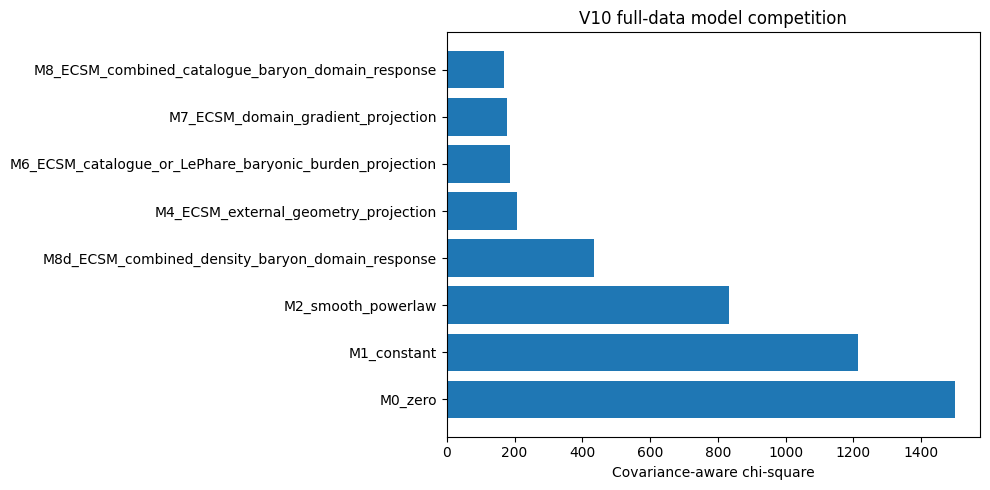

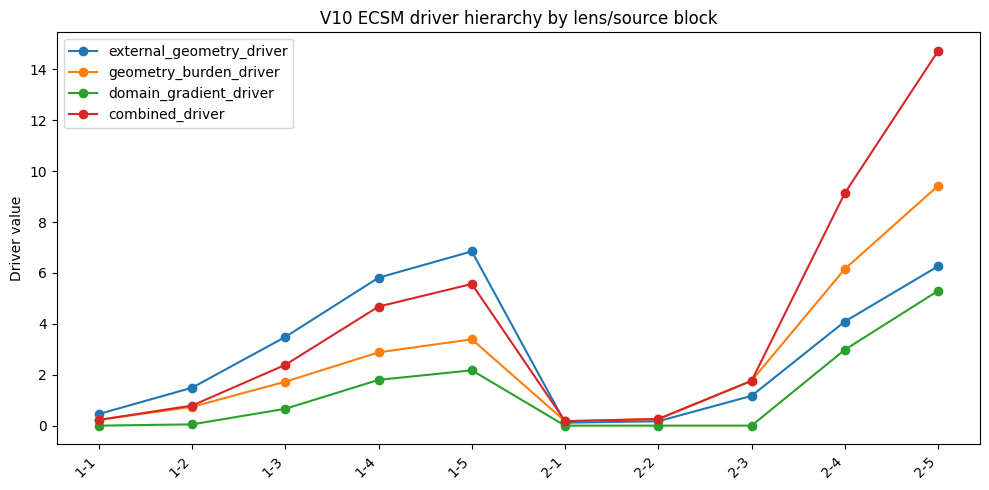

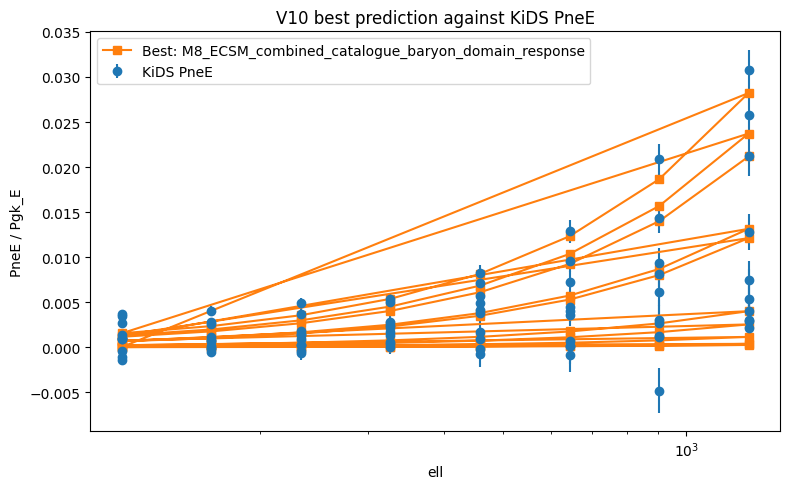

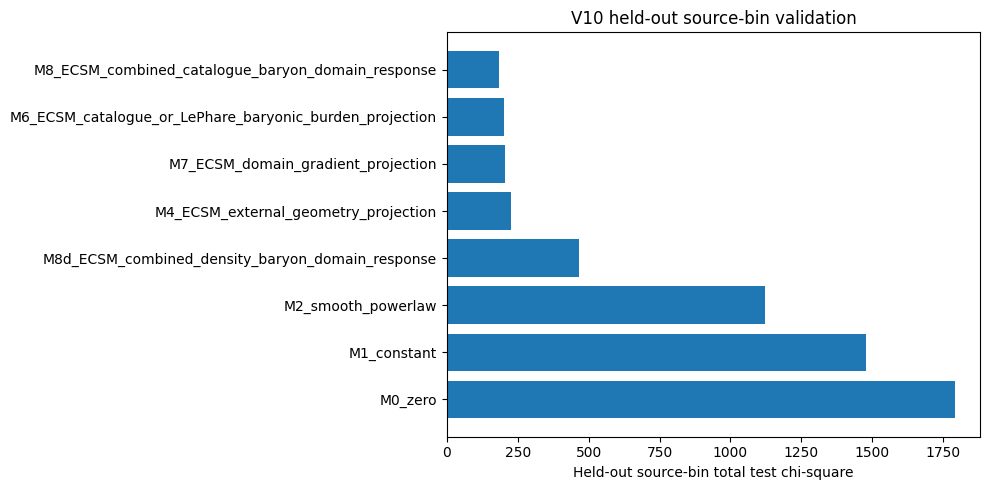

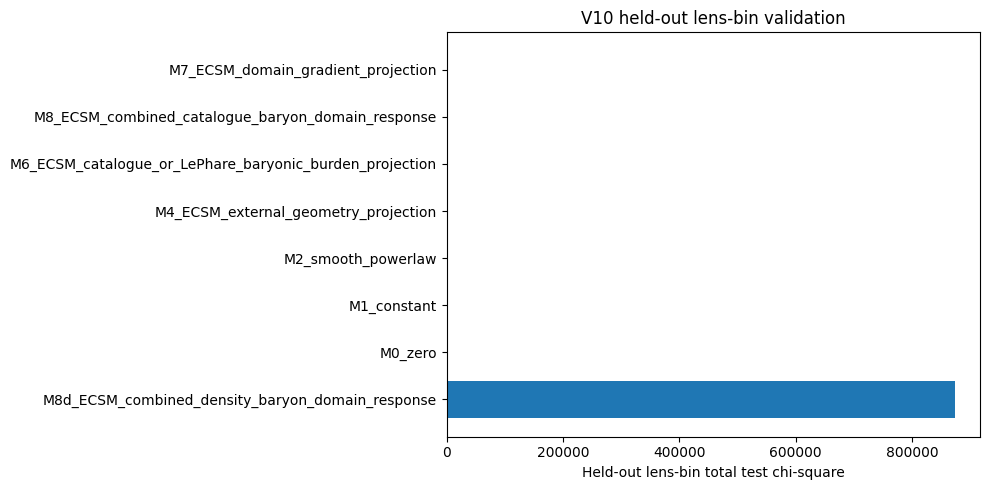

Figures saved in: /content/ecsm_kids_v10_catalogue_matched_baryonic_audit_out/figures


In [12]:
# CELL 11 — PREDICTIONS AND FIGURES
banner("CELL 11 — PREDICTIONS AND FIGURES")
pred=vec.copy()
for _,row in res.iterrows():
    name=row.model
    if name=="M0_zero": pred[name]=0.0
    elif name=="M1_constant": pred[name]=row.params["A"]
    elif name=="M2_smooth_powerlaw": pred[name]=row.params["A"]*(ell/ell0)**row.params["alpha"]
    else: pred[name]=pred_from_params(row.params["driver"],row.params)
pred.to_csv(TAB/"v10_predictions.csv",index=False); display(pred.head())
plt.figure(figsize=(10,5)); plot_res=res.sort_values("chi2",ascending=False); plt.barh(plot_res.model,plot_res.chi2); plt.xlabel("Covariance-aware chi-square"); plt.title("V10 full-data model competition"); plt.tight_layout(); plt.savefig(FIG/"v10_model_competition_chi2.png",dpi=180); plt.show()
driver_cols=["external_geometry_driver","geometry_burden_driver","domain_gradient_driver","combined_driver"]
dd=geom.copy(); dd["block"]=dd.lens_bin.astype(str)+"-"+dd.source_bin.astype(str)
plt.figure(figsize=(10,5))
for col in driver_cols: plt.plot(dd.block,dd[col],marker="o",label=col)
plt.xticks(rotation=45,ha="right"); plt.ylabel("Driver value"); plt.title("V10 ECSM driver hierarchy by lens/source block"); plt.legend(); plt.tight_layout(); plt.savefig(FIG/"v10_driver_hierarchy.png",dpi=180); plt.show()
best_model=res.iloc[0].model; plt.figure(figsize=(8,5)); plt.errorbar(vec.ell,vec.Pgk_E,yerr=vec.sigma_diag,fmt="o",label="KiDS PneE"); plt.plot(vec.ell,pred[best_model],marker="s",label=f"Best: {best_model}"); plt.xscale("log"); plt.xlabel("ell"); plt.ylabel("PneE / Pgk_E"); plt.title("V10 best prediction against KiDS PneE"); plt.legend(); plt.tight_layout(); plt.savefig(FIG/"v10_best_prediction_global.png",dpi=180); plt.show()
plt.figure(figsize=(10,5)); ss=source_summary.sort_values("total_test_chi2",ascending=False); plt.barh(ss.model,ss.total_test_chi2); plt.xlabel("Held-out source-bin total test chi-square"); plt.title("V10 held-out source-bin validation"); plt.tight_layout(); plt.savefig(FIG/"v10_heldout_source_summary.png",dpi=180); plt.show()
plt.figure(figsize=(10,5)); ls=lens_summary.sort_values("total_test_chi2",ascending=False); plt.barh(ls.model,ls.total_test_chi2); plt.xlabel("Held-out lens-bin total test chi-square"); plt.title("V10 held-out lens-bin validation"); plt.tight_layout(); plt.savefig(FIG/"v10_heldout_lens_summary.png",dpi=180); plt.show()
print("Figures saved in:",FIG)

In [13]:
# CELL 12 — README / SUMMARY REPORT
banner("CELL 12 — README / SUMMARY REPORT")
best=res.iloc[0].to_dict()
summary=f"""# ECSM_KiDS_V10_CatalogueMatched_BaryonicAudit

## Purpose

V10 attempts to promote the ECSM KiDS weak-lensing bridge into a catalogue-matched baryonic-burden test.

## Dataset

- Source repository: KiDS-WL `Cat_to_Obs_K1000_P1`
- FITS file: `{FITS_PATH.name}`
- Observable: `PneE`
- Data points: {N}
- Lens bins: {sorted(vec['lens_bin'].unique().tolist())}
- Source bins: {sorted(vec['source_bin'].unique().tolist())}
- Ell range: {vec['ell'].min():.6f} to {vec['ell'].max():.6f}
- Covariance shape: {C.shape}
- Covariance method: {cov_method}

## Physical stellar-mass catalogue

- Catalogue path: `{LEPHARE_PATH}`
- Redshift column: `{z_col}`
- Stellar mass column: `{mass_col}`
- Mass interpretation: `{mass_interpretation}`
- Usable rows after cuts: {len(tmp)}

## Exact foreground-lens catalogue audit

Catalogue matching status:

```json
{json.dumps(match_status, indent=2)}
```

Audit outputs:

```text
tables/v10_exact_foreground_lens_catalogue_audit.csv
tables/v10_match_status.csv
```

If status is `catalogue_matched_candidate_constructed`, the notebook found an object-level foreground-lens candidate and constructed a catalogue-matched burden table.

If status is `no_exact_lens_catalogue_found`, V10 remains an audit-and-promotion notebook. The model comparison then uses the V9-style LePhare lens-bin physical burden fallback.

## V10 drivers

```text
external_geometry_driver = lens/source projection proxy
geometry_burden_driver = external_geometry_driver × catalogue_or_LePhare_stellar_burden
domain_gradient_driver = geometry_burden_driver × domain_boundary_gradient_chi
combined_driver = geometry_burden_driver × (1 + domain_boundary_gradient_chi)
```

Lens-specific response scales:

```json
{json.dumps(ellB_by_lens, indent=2)}
```

## Full-data competition

{res.to_markdown(index=False)}

## Held-out source-bin validation

{source_summary.to_markdown(index=False)}

## Held-out lens-bin validation

{lens_summary.to_markdown(index=False)}

## Best full-data model

```json
{json.dumps(best, indent=2, default=str)}
```

## Interpretation guardrail

V10 separates two questions: whether a physical stellar-burden ECSM response chain can be tested against KiDS PneE, and whether the public data expose the exact foreground lens catalogue needed for a decisive object-matched baryonic prediction.

If the exact foreground catalogue is not found, this is not a failure of the ECSM model fit. It is a data-boundary result: the public compressed `PneE` product supplies bandpowers, covariance, and n(z), but not necessarily the object-level foreground lens catalogue with matched physical mass/luminosity/size fields.
"""
readme_path=OUT/"README.md"; readme_path.write_text(summary); print(summary[:5000]); print("\nSaved:",readme_path)


CELL 12 — README / SUMMARY REPORT
# ECSM_KiDS_V10_CatalogueMatched_BaryonicAudit

## Purpose

V10 attempts to promote the ECSM KiDS weak-lensing bridge into a catalogue-matched baryonic-burden test.

## Dataset

- Source repository: KiDS-WL `Cat_to_Obs_K1000_P1`
- FITS file: `bp_KIDS1000_BlindC_no_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits`
- Observable: `PneE`
- Data points: 80
- Lens bins: [1, 2]
- Source bins: [1, 2, 3, 4, 5]
- Ell range: 118.441992 to 1266.442730
- Covariance shape: (80, 80)
- Covariance method: cholesky

## Physical stellar-mass catalogue

- Catalogue path: `/content/drive/MyDrive/KiDS_DR4_brightsample_LePhare.fits`
- Redshift column: `REDSHIFT`
- Stellar mass column: `MASS_BEST`
- Mass interpretation: `log10(Mstar/Msun)`
- Usable rows after cuts: 1239422

## Exact foreground-lens catalogue audit

Catalogue matching status:

```json
{
  "status": "no_exact_lens_catalogue_found",
  "message": "No object-level foreg

In [14]:
# CELL 13 — ZIP OUTPUTS AND DOWNLOAD
banner("CELL 13 — ZIP OUTPUTS AND DOWNLOAD")
zip_path=Path("/content/ECSM_KiDS_V10_CatalogueMatched_BaryonicAudit_outputs.zip")
if zip_path.exists(): zip_path.unlink()
with zipfile.ZipFile(zip_path,"w",zipfile.ZIP_DEFLATED) as zf:
    for root,dirs,files in os.walk(OUT):
        for fn in files:
            p=Path(root)/fn; zf.write(p,p.relative_to(OUT.parent))
print("ZIP ready:",zip_path); print("Size MB:",zip_path.stat().st_size/1e6)
try:
    from google.colab import files; files.download(str(zip_path))
except Exception as e: print("Colab download unavailable:",repr(e))
try:
    drive_dir=Path("/content/drive/MyDrive/ECSM_KiDS_data"); drive_dir.mkdir(parents=True,exist_ok=True); shutil.copy2(zip_path,drive_dir/zip_path.name); print("Copied to Drive:",drive_dir/zip_path.name)
except Exception as e: print("Drive copy unavailable:",repr(e))


CELL 13 — ZIP OUTPUTS AND DOWNLOAD
ZIP ready: /content/ECSM_KiDS_V10_CatalogueMatched_BaryonicAudit_outputs.zip
Size MB: 217.69012


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Copied to Drive: /content/drive/MyDrive/ECSM_KiDS_data/ECSM_KiDS_V10_CatalogueMatched_BaryonicAudit_outputs.zip
